# Collate All Designs for Experimental Validation

This notebook assembles the final ~2,000 design library for high-throughput functional validation, combining designs from multiple computational methods.

**Prerequisites**: Run `prepare_final_designs_rational.ipynb` first to generate rational design CSV files.

## Input Files

**Design libraries** (generated from design notebooks):
- `final_designs/gRNAde_20032025.csv`: 1,000 designs from gRNAde pipeline with RibonanzaNet filtering
- `final_designs/gRNAde_extra_20032025.csv`: Additional gRNAde designs to fill order
- `final_designs/rational_heuristic_20032025.csv`: 500 rational designs WITH computational filtering
- `final_designs/rational_heuristic_random_20032025.csv`: 500 rational designs WITHOUT filtering

## Processing Steps

1. **Load design libraries**: Read CSV files from each design method
2. **Assign unique IDs**: Create FASTA descriptions (e.g., `var5TU_gRNAde0001`, `var5TU_rational0001`)
3. **Combine all designs**: Concatenate into single dataframe
4. **Add wild-type control**: Insert WT 5TU as first entry (edit_dist = 0)
5. **Add PCR primers**: Append flanking sequences for amplification (192 bp total)
6. **Convert RNA to DNA**: Replace U→T for sequencing compatibility
7. **Remove duplicates**: Ensure unique sequences in final library
8. **Quality check**: Visualize distributions of edit distance and computational scores

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# 1000 Designs from full gRNAde pipeline
df_grnade = pd.read_csv("final_designs/gRNAde_20032025.csv")
df_grnade["fasta_desc"] = "var5TU_gRNAde" + df_grnade.index.map(lambda x: f"{x+1:04d}")
df_grnade['model'] = 'gRNAde2'

# Some extra designs to fill out the order
df_grnade_extra = pd.read_csv("final_designs/gRNAde_extra_20032025.csv")
df_grnade_extra["fasta_desc"] = "var5TU_gRNAde_extra" + df_grnade_extra.index.map(lambda x: f"{x+1:04d}")
df_grnade_extra['model'] = 'gRNAde2_extra'

# 500 Designs from rational heuristic with filtering
df_rational = pd.read_csv("final_designs/rational_heuristic_20032025.csv")
df_rational["fasta_desc"] = "var5TU_rational" + df_rational.index.map(lambda x: f"{x+1:04d}")

# 500 Designs from rational heuristic without filtering (has some duplicates with filtered set)
df_random = pd.read_csv("final_designs/rational_heuristic_random_20032025.csv")
df_random["fasta_desc"] = "var5TU_random" + df_random.index.map(lambda x: f"{x+1:04d}")

In [ ]:
# All designs collated
df_final_designs = pd.concat(
    [
        df_grnade, 
        df_grnade_extra,
        df_rational, 
        df_random
    ],
    ignore_index=True
)
df_final_designs

,fasta_desc,sequence,model,seed,temperature,edit_dist,perplexity,sc_score_ribonanzanet,sc_score_ribonanzanet_ss
0,var5TU_gRNAde0001,GGAUCUUCUCGAUCUAUUAAAAAAGACAAAUCUGCCACAAAGCUUG...,gRNAde2,3090,0.441924,15,1.235233,0.081990,0.809393
1,var5TU_gRNAde0002,GGAUCUUCUCGAUCUAAUCAAAAAGACAAAUCUGCCACAAAGCUUG...,gRNAde2,6802,0.632620,15,1.212259,0.083147,0.830978
2,var5TU_gRNAde0003,GGAUCUUCUCGAUCUAACCAACAAGACAAAUCUGCCACAAAGCUUG...,gRNAde2,6802,0.632620,15,1.197458,0.089538,0.830978
3,var5TU_gRNAde0004,GGAUCUUCUCGAUCCACGAAACAAGACAAAUCUGCCACAAUGCUUG...,gRNAde2,3809,0.743550,15,1.171488,0.091939,0.917109
4,var5TU_gRNAde0005,GGAUCUUCUCGAUCUAUUCUACAAGACAAAUCUGCCAGAAUGCUUG...,gRNAde2,8374,0.327370,15,1.167326,0.092202,0.872379
...,...,...,...,...,...,...,...,...,...
2006,var5TU_random0496,GGAUAUUCUCGAUUCUAGCAAUAAGACAAAUCUGCCUCAUGGCUUC...,rational_heuristic_random,4623,0.523349,39,0.000000,0.242460,0.104234
2007,var5TU_random0497,GGACCUUCUCGGUCUGGCACUUAAGACAAAUCUGCCGUAAAGCUUU...,rational_heuristic_random,1824,0.624356,39,0.000000,0.243123,0.377730
2008,var5TU_random0498,GGAUUUUCUCGAUCUACCAAUCAAGACAAAUCUGUACAAACGCUUG...,rational_heuristic_random,492,1.169611,39,0.000000,0.203848,0.691423
2009,var5TU_random0499,GGCUCUUCUCGAGCUAAGGAUUAAGACAAAUCUGCCAGAGAGCUUA...,rational_heuristic_random,3657,1.257757,39,0.000000,0.203082,0.516794


/home/ckj24/miniforge-pypy3/envs/rna/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ckj24/miniforge-pypy3/envs/rna/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ckj24/miniforge-pypy3/envs/rna/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/hom

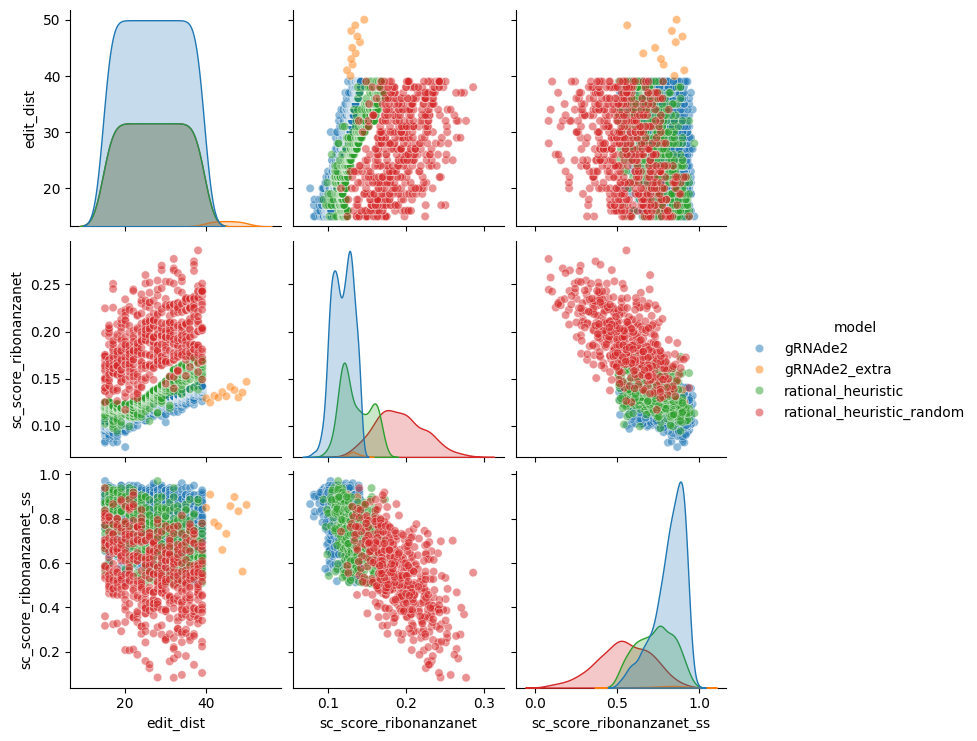

In [4]:
sns.pairplot(
    df_final_designs, 
    x_vars=['edit_dist', 'sc_score_ribonanzanet', 'sc_score_ribonanzanet_ss'],
    y_vars=['edit_dist', 'sc_score_ribonanzanet', 'sc_score_ribonanzanet_ss'],
    hue='model',
    plot_kws={'alpha': 0.5}
)
plt.show()

In [5]:
fivetu_seq = "GGAUCUUCUCGAUCUAACAAAAAAGACAAAUCUGCCACAAAGCUUGAGAGCAUCUUCGGAUGCAGAGGCGGCAGCCUUCGGUGGCGCGAUAGCGCCAACGUUCUCAACUAUGACACGCAAAACGCGUGCUCCGUUGAAUGGAGUUUAUCAUG"

# Add 5TU sequence to final designs as first entry
df_final_designs = pd.concat(
    [
        pd.DataFrame(
            {
                'fasta_desc': ['5TU'],
                'sequence': [fivetu_seq],
                'edit_dist': [0],
                'sc_score_ribonanzanet': [0],
                'sc_score_ribonanzanet_ss': [1.0],
                'model': ['WT'],
                'seed': [0],
                'temperature': [0],
                'perplexity': [1.0],
            }
        ),
        df_final_designs
    ],
    ignore_index=True
)
df_final_designs

,fasta_desc,sequence,edit_dist,sc_score_ribonanzanet,sc_score_ribonanzanet_ss,model,seed,temperature,perplexity
0,5TU,GGAUCUUCUCGAUCUAACAAAAAAGACAAAUCUGCCACAAAGCUUG...,0,0.000000,1.000000,WT,0,0.000000,1.000000
1,var5TU_gRNAde0001,GGAUCUUCUCGAUCUAUUAAAAAAGACAAAUCUGCCACAAAGCUUG...,15,0.081990,0.809393,gRNAde2,3090,0.441924,1.235233
2,var5TU_gRNAde0002,GGAUCUUCUCGAUCUAAUCAAAAAGACAAAUCUGCCACAAAGCUUG...,15,0.083147,0.830978,gRNAde2,6802,0.632620,1.212259
3,var5TU_gRNAde0003,GGAUCUUCUCGAUCUAACCAACAAGACAAAUCUGCCACAAAGCUUG...,15,0.089538,0.830978,gRNAde2,6802,0.632620,1.197458
4,var5TU_gRNAde0004,GGAUCUUCUCGAUCCACGAAACAAGACAAAUCUGCCACAAUGCUUG...,15,0.091939,0.917109,gRNAde2,3809,0.743550,1.171488
...,...,...,...,...,...,...,...,...,...
2007,var5TU_random0496,GGAUAUUCUCGAUUCUAGCAAUAAGACAAAUCUGCCUCAUGGCUUC...,39,0.242460,0.104234,rational_heuristic_random,4623,0.523349,0.000000
2008,var5TU_random0497,GGACCUUCUCGGUCUGGCACUUAAGACAAAUCUGCCGUAAAGCUUU...,39,0.243123,0.377730,rational_heuristic_random,1824,0.624356,0.000000
2009,var5TU_random0498,GGAUUUUCUCGAUCUACCAAUCAAGACAAAUCUGUACAAACGCUUG...,39,0.203848,0.691423,rational_heuristic_random,492,1.169611,0.000000
2010,var5TU_random0499,GGCUCUUCUCGAGCUAAGGAUUAAGACAAAUCUGCCAGAGAGCUUA...,39,0.203082,0.516794,rational_heuristic_random,3657,1.257757,0.000000


In [6]:
# Add flanking sequences to final designs
left_seq = 'AACAAACAACAAAACAAACAAACA'
right_seq = 'GGGTCGGCATGGCATC'
df_final_designs['sequence_with_flanking'] = left_seq + df_final_designs['sequence'] + right_seq

# Change RNA to DNA by substituting Us with Ts in sequence_with_flanking
df_final_designs['sequence'] = df_final_designs['sequence'].str.replace('U', 'T')
df_final_designs['sequence_with_flanking'] = df_final_designs['sequence_with_flanking'].str.replace('U', 'T')
df_final_designs

,fasta_desc,sequence,edit_dist,sc_score_ribonanzanet,sc_score_ribonanzanet_ss,model,seed,temperature,perplexity,sequence_with_flanking
0,5TU,GGATCTTCTCGATCTAACAAAAAAGACAAATCTGCCACAAAGCTTG...,0,0.000000,1.000000,WT,0,0.000000,1.000000,AACAAACAACAAAACAAACAAACAGGATCTTCTCGATCTAACAAAA...
1,var5TU_gRNAde0001,GGATCTTCTCGATCTATTAAAAAAGACAAATCTGCCACAAAGCTTG...,15,0.081990,0.809393,gRNAde2,3090,0.441924,1.235233,AACAAACAACAAAACAAACAAACAGGATCTTCTCGATCTATTAAAA...
2,var5TU_gRNAde0002,GGATCTTCTCGATCTAATCAAAAAGACAAATCTGCCACAAAGCTTG...,15,0.083147,0.830978,gRNAde2,6802,0.632620,1.212259,AACAAACAACAAAACAAACAAACAGGATCTTCTCGATCTAATCAAA...
3,var5TU_gRNAde0003,GGATCTTCTCGATCTAACCAACAAGACAAATCTGCCACAAAGCTTG...,15,0.089538,0.830978,gRNAde2,6802,0.632620,1.197458,AACAAACAACAAAACAAACAAACAGGATCTTCTCGATCTAACCAAC...
4,var5TU_gRNAde0004,GGATCTTCTCGATCCACGAAACAAGACAAATCTGCCACAATGCTTG...,15,0.091939,0.917109,gRNAde2,3809,0.743550,1.171488,AACAAACAACAAAACAAACAAACAGGATCTTCTCGATCCACGAAAC...
...,...,...,...,...,...,...,...,...,...,...
2007,var5TU_random0496,GGATATTCTCGATTCTAGCAATAAGACAAATCTGCCTCATGGCTTC...,39,0.242460,0.104234,rational_heuristic_random,4623,0.523349,0.000000,AACAAACAACAAAACAAACAAACAGGATATTCTCGATTCTAGCAAT...
2008,var5TU_random0497,GGACCTTCTCGGTCTGGCACTTAAGACAAATCTGCCGTAAAGCTTT...,39,0.243123,0.377730,rational_heuristic_random,1824,0.624356,0.000000,AACAAACAACAAAACAAACAAACAGGACCTTCTCGGTCTGGCACTT...
2009,var5TU_random0498,GGATTTTCTCGATCTACCAATCAAGACAAATCTGTACAAACGCTTG...,39,0.203848,0.691423,rational_heuristic_random,492,1.169611,0.000000,AACAAACAACAAAACAAACAAACAGGATTTTCTCGATCTACCAATC...
2010,var5TU_random0499,GGCTCTTCTCGAGCTAAGGATTAAGACAAATCTGCCAGAGAGCTTA...,39,0.203082,0.516794,rational_heuristic_random,3657,1.257757,0.000000,AACAAACAACAAAACAAACAAACAGGCTCTTCTCGAGCTAAGGATT...


In [7]:
# Remove duplicates
df_final_designs = df_final_designs.drop_duplicates(subset="sequence")

# Print number of designs per model
df_final_designs['model'].value_counts()

model
gRNAde2                      1000
rational_heuristic            500
rational_heuristic_random     488
gRNAde2_extra                  11
WT                              1
Name: count, dtype: int64

In [ ]:
# Save as csv
df_final_designs.to_csv("final_designs/all_designs_20032025.csv", index=False)

In [ ]:
# Save as fasta
with open("final_designs/all_designs_20032025.fasta", "w") as f:
    for i, row in df_final_designs.iterrows():
        f.write(f">{row['fasta_desc']}\n")
        f.write(f"{row['sequence_with_flanking']}\n")